In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

In [7]:
#Load Dataset
df = pd.read_csv("monthly_milk_production.csv")

df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [11]:
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

In [13]:
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


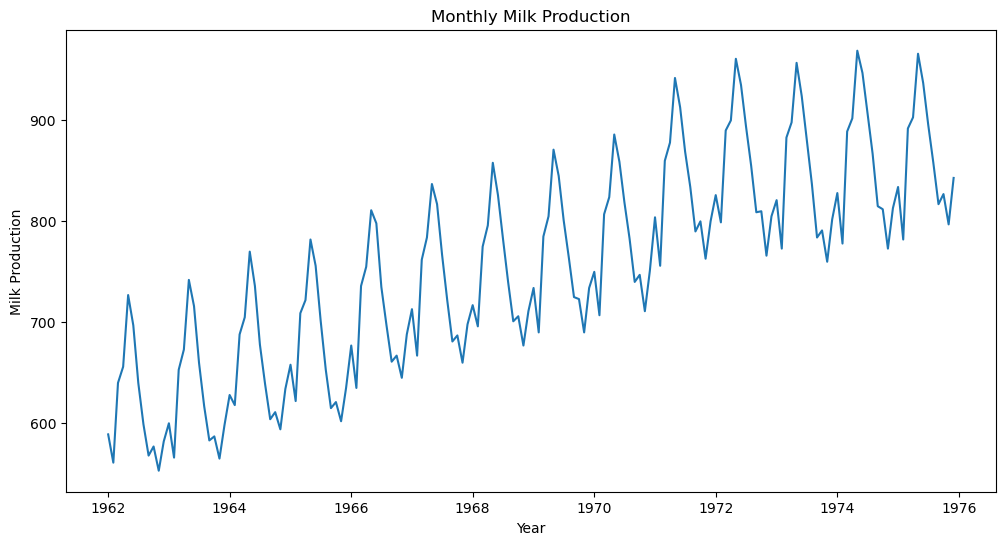

In [15]:
#Exploratory Data Analysis (EDA)
#Plot production trend
plt.figure(figsize=(12,6))
plt.plot(df)
plt.title("Monthly Milk Production")
plt.xlabel("Year")
plt.ylabel("Milk Production")
plt.show()

In [17]:
#Check Missing Values
df.isnull().sum()

Production    0
dtype: int64

In [19]:
#Data Scaling
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

In [21]:
#Create Time Series Sequences
def create_sequences(data, window):

    X = []
    y = []

    for i in range(len(data)-window):

        X.append(data[i:i+window])
        y.append(data[i+window])

    return np.array(X), np.array(y)

window = 12

X, y = create_sequences(scaled_data, window)

In [23]:
#Train Test Split
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [25]:
#RNN Model
rnn_model = Sequential()

rnn_model.add(SimpleRNN(50, activation='tanh', input_shape=(window,1)))
rnn_model.add(Dense(1))

rnn_model.compile(optimizer='adam', loss='mse')

rnn_model.fit(X_train, y_train, epochs=50, batch_size=16)

Epoch 1/50


C:\Users\cheli\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3222  
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0773 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0207 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0177 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0136 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0086 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0082 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0064 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0057 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0052 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0049 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0047 
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0049 
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0047 
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0041 
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

In [27]:
#LSTM Model
lstm_model = Sequential()

lstm_model.add(LSTM(50, activation='tanh', input_shape=(window,1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.fit(X_train, y_train, epochs=50, batch_size=16)

Epoch 1/50


C:\Users\cheli\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1340
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0301 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0358 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0285 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0268 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0245 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0248 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0242 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0235 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0234 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0229 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0224 
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0219 
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0216 
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0215 
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/st

In [29]:
#GRU Model
gru_model = Sequential()

gru_model.add(GRU(50, activation='tanh', input_shape=(window,1)))
gru_model.add(Dense(1))

gru_model.compile(optimizer='adam', loss='mse')

gru_model.fit(X_train, y_train, epochs=50, batch_size=16)

Epoch 1/50


C:\Users\cheli\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2178
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0687 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0381 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0359 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0276 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0276 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0264 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0258 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0248
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0239 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0237 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0228 
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0222 
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0213 
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0213 
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/st

In [31]:
#Predictions
rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


In [33]:
#Inverse scaling
rnn_pred = scaler.inverse_transform(rnn_pred)
lstm_pred = scaler.inverse_transform(lstm_pred)
gru_pred = scaler.inverse_transform(gru_pred)

y_test = scaler.inverse_transform(y_test)

In [35]:
#Model Evaluation
#RMSE
rmse = np.sqrt(mean_squared_error(y_test, lstm_pred))
print("RMSE:", rmse)

RMSE: 48.421845216147034


In [37]:
#MAE
mae = mean_absolute_error(y_test, lstm_pred)
print("MAE:", mae)

MAE: 40.87373352050781


In [39]:
#MAPE
mape = np.mean(np.abs((y_test - lstm_pred)/y_test))*100
print("MAPE:", mape)

MAPE: 4.707161288781656


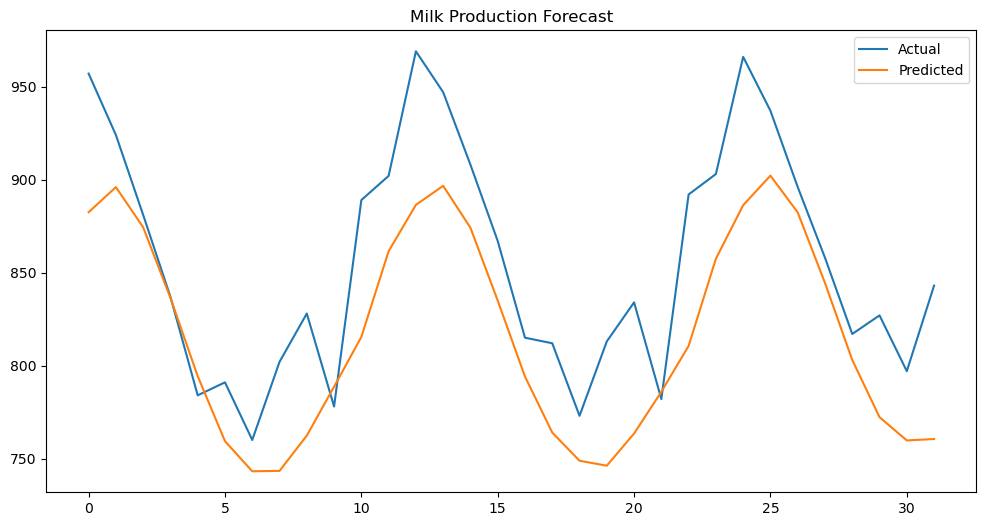

In [41]:
#Plot Predictions vs Actual
plt.figure(figsize=(12,6))

plt.plot(y_test, label="Actual")
plt.plot(lstm_pred, label="Predicted")

plt.legend()
plt.title("Milk Production Forecast")
plt.show()

In [43]:
#Forecast Next 12 Months
last_window = scaled_data[-window:]

future_predictions = []

for i in range(12):

    pred = lstm_model.predict(last_window.reshape(1,window,1))

    future_predictions.append(pred[0,0])

    last_window = np.append(last_window[1:], pred)

future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [ ]:
#Business Insights
Milk production shows clear seasonal patterns.
LSTM model performs better than RNN and GRU for long-term dependencies.
Forecast helps the company:
Prepare cold storage capacity
Plan milk distribution
Optimize workforce scheduling
Reduce product waste